In [1]:
import sys
import plotly
import kaleido

print(sys.executable)
print("plotly:", plotly.__version__)
print("kaleido:", kaleido.__version__)

/home/igor/anaconda3/envs/cnn_plastic/bin/python
plotly: 6.0.0
kaleido: 0.2.1


In [20]:
import os 
from tqdm import tqdm
import pandas as pd
import subprocess
import pickle
import ast
import numpy as np
import pickle

import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.lines as mlines

In [4]:
#REQUIRED FUNCTIONS

In [5]:
def plot_interactive(x, y, polymer):
    destination_file = polymer+'.html'

    r_spectral_data = FloatVector(y)
    r_matrix = r['matrix'](r_spectral_data, nrow=1, ncol=len(r_spectral_data))
    fourS = ro.r('baseline.fillPeaks')
    fourS_result = fourS(r_matrix, 4, 25, 10, 355)
    corrected_data_4s = [max(0, x) for x in list(fourS_result[1])] #list(fourS_result[1])
    baseline_data_4s = list(fourS_result[0])
    
    # Create interactive plot
    fig = go.Figure()
    
    # Original data
    fig.add_trace(go.Scatter(x=x, y=y, mode='lines', name='Averaged (Original)', line=dict(color='blue')))

    # Corrected data
    fig.add_trace(go.Scatter(x=x, y=corrected_data_4s, mode='lines', name='Averaged (Baseline corr.)', line=dict(color='red')))
    
    # Update layout
    fig.update_layout(title=f"Plot for {polymer}", xaxis_title="X", yaxis_title="Y", template="plotly_white")

    # Save plot as an interactive HTML file
    #output_file = file.replace(".csv", ".html").replace('PE_after_matching','PE_interactive')
    fig.write_html(destination_file)

In [6]:
def plot_interactive_all_corr(x1, y1, polymer1, x2, y2, polymer2, x3, y3, polymer3):
    destination_file = 'all_baseline_corr.html'

    r_spectral_data = FloatVector(y1)
    r_matrix = r['matrix'](r_spectral_data, nrow=1, ncol=len(r_spectral_data))
    fourS = ro.r('baseline.fillPeaks')
    fourS_result = fourS(r_matrix, 4, 25, 10, 355)
    corrected_data_4s_1 = [max(0, x) for x in list(fourS_result[1])] #list(fourS_result[1])

    r_spectral_data = FloatVector(y2)
    r_matrix = r['matrix'](r_spectral_data, nrow=1, ncol=len(r_spectral_data))
    fourS = ro.r('baseline.fillPeaks')
    fourS_result = fourS(r_matrix, 4, 25, 10, 355)
    corrected_data_4s_2 = [max(0, x) for x in list(fourS_result[1])] #list(fourS_result[1])

    r_spectral_data = FloatVector(y3)
    r_matrix = r['matrix'](r_spectral_data, nrow=1, ncol=len(r_spectral_data))
    fourS = ro.r('baseline.fillPeaks')
    fourS_result = fourS(r_matrix, 4, 25, 10, 355)
    corrected_data_4s_3 = [max(0, x) for x in list(fourS_result[1])] #list(fourS_result[1])
    
    # Create interactive plot
    fig = go.Figure()

    #PE
    fig.add_trace(go.Scatter(x=x1, y=corrected_data_4s_1, mode='lines', name=polymer1, line=dict(color='red')))
    
    #PP
    fig.add_trace(go.Scatter(x=x2, y=corrected_data_4s_2, mode='lines', name=polymer2, line=dict(color='green')))

    #PS
    fig.add_trace(go.Scatter(x=x3, y=corrected_data_4s_3, mode='lines', name=polymer3, line=dict(color='blue')))
    
    # Update layout
    fig.update_layout(title=f"Plot for {polymer}", xaxis_title="X", yaxis_title="Y", template="plotly_white")

    # Save plot as an interactive HTML file
    #output_file = file.replace(".csv", ".html").replace('PE_after_matching','PE_interactive')
    fig.write_html(destination_file)

In [7]:
def plot_sankey(mpsat_results, polymer_type):
    # Example: Your DataFrame (df) contains "true" and "predicted" columns
    true_labels = mpsat_results["true"]
    predicted_labels = mpsat_results["predicted"]
    
    # Select the true class to analyze (e.g., PE)
    true_class = polymer_type
    mpsat_results_filtered = mpsat_results[mpsat_results["true"] == true_class]
    
    # Count occurrences of each predicted class for PE
    class_counts = mpsat_results_filtered["predicted"].value_counts()
    
    # Define source (true class) and target (predicted classes)
    source = [0] * len(class_counts)  # All from "PE" (index 0)
    target = list(range(1, len(class_counts) + 1))  # Unique predicted class indices
    values = class_counts.values  # Corresponding count for each prediction
    
    # Create node labels with counts included
    labels = [f"{true_class} ({mpsat_results_filtered.shape[0]})"] + [f"{cls} ({count})" for cls, count in zip(class_counts.index, values)]
    
    # Create the Sankey diagram
    fig = go.Figure(go.Sankey(
        node=dict(
            pad=20,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=labels,
        ),
        link=dict(
            source=source,
            target=target,
            value=values,
        )
    ))
    
    #fig.update_layout(title_text=f"Correspondence Between '{true_class}' and Predicted Classes", font_size=16)
    #fig.write_image(f"{polymer_type}_sankey_diagram.png", scale=3)
    fig.show()

In [8]:
def plot_all_sankey_single(mpsat_results, polymer_types, height_par):
    num_polymers = len(polymer_types)

    pt2panel_name = {'PE' : '(a)', 'PP' : '(b)', 'PS' : '(c)'}
    
    # Define A4 width in pixels (≈ 800px for good fit)
    fig_width = 350  # Adjusted for A4 width

    # Adjust padding & thickness for better spacing
    pad_settings = {"PE": 20, "PP": 15, "PS": 10}
    thickness_settings = {"PE": 10, "PP": 10, "PS": 10}

    # Set different heights for each polymer type
    height_settings = {"PE": 400, "PP": 200, "PS": 100}  # Adjust these values based on your preference

    # Create a 1-row, multiple-column subplot layout
    fig = make_subplots(
        rows=1, cols=num_polymers,  # All plots in one row 
        specs=[[{"type": "sankey"}] * num_polymers], 
        horizontal_spacing=0.1,  # Reduce spacing for compact layout
        subplot_titles=[f"{pt2panel_name[polymer_types[0]]}"]
    )

    for i, polymer_type in enumerate(polymer_types):
        # Filter data for the polymer type
        mpsat_results_filtered = mpsat_results[mpsat_results["true"] == polymer_type]
        class_counts = mpsat_results_filtered["predicted"].value_counts()

        if class_counts.empty:
            print(f"No data for {polymer_type}, skipping...")
            continue

        # Define source & target
        source = [0] * len(class_counts)
        target = list(range(1, len(class_counts) + 1))
        values = class_counts.values

        # Labels for nodes
        labels = [f"{polymer_type} ({mpsat_results_filtered.shape[0]})"] + \
                 [f"{cls} ({count})" for cls, count in zip(class_counts.index, values)]

        # Adjust node positioning (x: left-right placement)
        node_positions = [0.3] + [0.7] * len(class_counts)

        # Create Sankey trace
        sankey_trace = go.Sankey(
            node=dict(
                pad=pad_settings.get(polymer_type, 10),
                thickness=thickness_settings.get(polymer_type, 8),
                line=dict(color="black", width=0.1),
                label=labels,
                x=node_positions
            ),
            link=dict(
                source=source,
                target=target,
                value=values
            )
        )

        # Add trace to subplot
        fig.add_trace(sankey_trace, row=1, col=i + 1)

    # Update layout for each subplot with appropriate height for each polymer
    fig.update_layout(
        font_size=10,
        width=fig_width,
        height=height_par,  # Use the max height to maintain consistency
        autosize=False,
        title_x=0,  # Move titles to the left (horizontal position)
        title_y=1,  # Move titles closer to the plot (vertical position)
        title_font=dict(size=12),  # Optional: Adjust font size of the titles
        showlegend=False  # Optional: Hide the legend if not needed
    )

    # Save as PNG
    if len(polymer_types) == 1:
        file_name = f"{polymer_types[0]}_sankey_plots_compact.png"
    else:
        print('DEFINE FILENAME')
        sys.exit()
    fig.write_image(file_name, scale=3)
    print(f"Saved: {file_name}")

    # Show figure
    #fig.show()

In [9]:
def plot_data_single_panel(mpsat_results, initial_db, true_type, predicted_types, panel_label_symbol):
    """
    Plot a single panel for a specified polymer type.

    Parameters:
        dataframe (pd.DataFrame): The data to plot.R
        filename (str): Name of the output PNG file.
        polymer_type (str): The polymer class to plot (e.g., 'PP', 'PE', 'PS').
        color (str): The color for the polymer type.
    """
    
    # A4 paper dimensions in inches: (width=8.3, height is reduced below)
    a4_width_inches = 8.3
    reduced_height_inches = 3.0  # Adjust height for a single panel

    # Wavenumber positions for vertical lines
    wavenumbers = {
        'PE' : [2915, 2845, 1472, 1467, 1377, 1462, 730, 717],
        'PA' : [687, 1199, 1274, 1372, 1464, 1538, 1634, 2858, 2932, 3298],
        'PP' : [2950, 2915, 2838, 1455, 1377, 1166, 997, 972, 840, 808],
        'PS' : [3024, 2847, 1601, 1492, 1451, 1027, 694, 537],
        'PVC': [616, 966, 1099, 1255, 1331, 1427],
        'PU' : [1223, 1451, 1531, 1731, 2865],
        'EVA': [720, 1020, 1241, 1469, 1740, 2848, 2917],
        'CPE': [2965, 2926, 2854, 1468, 1260, 653],
        'PC' : [828, 1013, 1158, 1186, 1364, 1409, 1503, 1768, 2966],
        'CA' : [600, 904, 1368, 1743],
        'PET': [720, 1094, 1241, 1713],
        ''   : []
    }
    
    # Create a figure with a single subplot
    fig, ax = plt.subplots(1, 1, figsize=(a4_width_inches, reduced_height_inches))

    # Panel label
    panel_label = panel_label_symbol

    # Filter data for the current polymer type
    list_ = mpsat_results.loc[(df["true"] == true_type) & (df["predicted"] == predicted_types), "File name"].to_list()
    selected = initial_db[initial_db["File name"].isin(list_)]    
    
    # Extract x-axis values from column names (assuming data starts from column index 7)
    x_values = np.array([float(col) for col in selected.columns[7:]])
    
    # Prepare y-axis values for each row
    y_values = selected.iloc[:, 7:].values

    # Plot data for the current polymer type
    for i in range(len(y_values)):
        ax.plot(x_values, y_values[i], color='black', linewidth=1.5)  # Black outline
        ax.plot(x_values, y_values[i], color='gray', linewidth=1)      # Inner color

    # Add gray vertical lines at characteristic wavenumbers
    polymers_for_peaks = [true_type] + [item for item in predicted_types.split('+') if item not in [true_type]]
    #print(polymers_for_peaks)
    colors             = ['red', 'blue', 'green']
    for pol,col in zip(polymers_for_peaks, colors):
        for wn in wavenumbers[pol]:
            ax.axvline(x=wn, color=col, linestyle='--', linewidth=1.5, alpha=0.5)

    # Set labels and limits
    ax.set_ylabel("Absorbance, a.u.", fontsize=12, fontweight='bold')
    #ax.set_ylim(-0.02, 0.35)
    ax.tick_params(axis='y', labelsize=14)

    # Add panel label (a)
    ax.text(0.01, 0.9, panel_label, transform=ax.transAxes, fontsize=14, fontweight='bold')

    legend_lines = []
    legend_line_1 = mlines.Line2D([], [], color='gray', linewidth=2, label=true_type+' spectra')
    legend_lines.append(legend_line_1)

    for pol,col in zip(polymers_for_peaks, colors):
        legend_line_ = mlines.Line2D([], [], color=col, linewidth=2, label=pol+' lines')
        legend_lines.append(legend_line_)
        
    # Add all legend lines in a single call to ax.legend()
    ax.legend(handles=legend_lines,
              loc='upper right',  # Adjust location
              fontsize=12,
              frameon=False,
              bbox_to_anchor=(1.01, 1),  # Adjust this to move the legend outside the plot
              borderaxespad=0.5,  # Adds some space between the legend and plot
              ncol=1)  # Ensures the legend is stacked vertically (1 column)
    
    # Add x-axis label
    ax.set_xlabel("Wavenumber, cm$^{-1}$", fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', labelsize=14)
    ax.set_xlim(450, 4000)

    # Adjust layout for resized A4 dimensions and spacing
    plt.tight_layout()

    # Save the figure as a PNG file
    plt.savefig(f"{panel_label_symbol}_{true_type}={predicted_types}_absorbance.png", dpi=600, bbox_inches='tight')

    # Show the plot
    plt.show()

In [10]:
def plot_data_single_panel_interactive(mpsat_results, initial_db, true_type, predicted_types, panel_label_symbol):
    """
    Plot a single panel for a specified polymer type using Plotly and save it as an interactive HTML file.
    """
    # Wavenumber positions for vertical lines
    wavenumbers = {
        'PE': [2915, 2845, 1472, 1467, 1377, 1462, 730, 717],
        'PA': [687, 1199, 1274, 1372, 1464, 1538, 1634, 2858, 2932, 3298],
        'PP': [2950, 2915, 2838, 1455, 1377, 1166, 997, 972, 840, 808],
        'PS': [3024, 2847, 1601, 1492, 1451, 1027, 694, 537],
        'PVC': [616, 966, 1099, 1255, 1331, 1427],
        'PU': [1223, 1451, 1531, 1731, 2865],
        'EVA': [720, 1020, 1241, 1469, 1740, 2848, 2917],
        'CPE': [2965, 2926, 2854, 1468, 1260, 653],
        'PC': [828, 1013, 1158, 1186, 1364, 1409, 1503, 1768, 2966],
        'CA': [600, 904, 1368, 1743],
        'PET': [720, 1094, 1241, 1713],
        '': []
    }
        
    # Filter data for the current polymer type
    list_ = mpsat_results.loc[(mpsat_results["true"] == true_type) & (mpsat_results["predicted"] == predicted_types), "File name"].to_list()
    selected = initial_db[initial_db["File name"].isin(list_)] 
    
    # Extract x-axis values from column names (assuming data starts from column index 7)
    x_values = np.array([float(col) for col in selected.columns[7:]])
    
    # Prepare y-axis values for each row
    y_values = selected.iloc[:, 7:].values
    file_names = selected["File name"].values  # Extract file names
    
    # Create the figure using Plotly
    fig = go.Figure()

    # Plot data with file name on hover
    for i in range(len(y_values)):
        fig.add_trace(go.Scatter(
            x=x_values, 
            y=y_values[i], 
            mode='lines', 
            line=dict(color='gray', width=1), 
            showlegend=False,
            name=file_names[i],  # Use file name in legend
            hovertemplate=f"File: {file_names[i]}<br>Wavenumber: %{{x}} cm⁻¹<br>Absorbance: %{{y}} a.u."
        ))

    # Add gray vertical lines at characteristic wavenumbers for both polymer types
    polymers_for_peaks = [true_type] + [item for item in predicted_types.split('+') if item not in [true_type]]
    colors = ['red', 'blue', 'green']
    for pol, col in zip(polymers_for_peaks, colors):
        for wn in wavenumbers[pol]:
            fig.add_vline(x=wn, line=dict(color=col, dash='dash', width=1.5), opacity=0.5)
    
    # Add legend entries
    fig.add_trace(go.Scatter(x=[None], y=[None], mode='lines', name=true_type+' spectra', line=dict(color='gray', width=2)))
    for pol, col in zip(polymers_for_peaks, colors):
        fig.add_trace(go.Scatter(x=[None], y=[None], mode='lines', name=pol+' lines', line=dict(color=col, width=2)))

    # Set layout properties
    fig.update_layout(
        title=f"{true_type} spectra classified as {predicted_types}",
        xaxis_title="Wavenumber, cm<sup>-1</sup>",
        yaxis_title="Absorbance, a.u.",
        xaxis=dict(range=[450, 4000]),
        yaxis=dict(range=[-0.02, 0.6]),
        showlegend=True,
        legend=dict(
            x=1.05, y=1, traceorder='normal', orientation='v', xanchor='left', yanchor='top'
        ),
        font=dict(size=12),
        height=500,
        margin=dict(l=50, r=150, t=50, b=50)
    )

    # Save the plot as an interactive HTML file
    fig.write_html(f"./interactive/{true_type}={predicted_types}_interactive.html")

    return selected

In [34]:
def plot_data_single_panel_average(mpsat_results, initial_db, true_type, predicted_types, panel_label_symbol):
    """
    Plot a single panel with one averaged spectrum for spectra matching
    the specified true and predicted polymer classes.

    Parameters:
        mpsat_results (pd.DataFrame): Table with columns "true", "predicted", and "File name".
        initial_db (pd.DataFrame): Spectral database. Spectral columns are assumed to start from column index 7.
        true_type (str): True polymer class, e.g. 'PE', 'PP', 'PS'.
        predicted_types (str): Predicted polymer class/classes, e.g. 'PE' or 'PE+PP'.
        panel_label_symbol (str): Panel label shown in the upper-left corner and used in the filename.
    """

    # A4 paper dimensions in inches: (width=8.3, height is reduced below)
    a4_width_inches = 8.3
    reduced_height_inches = 3.0  # Adjust height for a single panel

    # Wavenumber positions for vertical lines
    wavenumbers = {
        'PE' : [2915, 2845, 1472, 1467, 1377, 1462, 730, 717],
        'PA' : [687, 1199, 1274, 1372, 1464, 1538, 1634, 2858, 2932, 3298],
        'PP' : [2950, 2915, 2838, 1455, 1377, 1166, 997, 972, 840, 808],
        'PS' : [3024, 2847, 1601, 1492, 1451, 1027, 694, 537],
        'PVC': [616, 966, 1099, 1255, 1331, 1427],
        'PU' : [1223, 1451, 1531, 1731, 2865],
        'EVA': [720, 1020, 1241, 1469, 1740, 2848, 2917],
        'CPE': [2965, 2926, 2854, 1468, 1260, 653],
        'PC' : [828, 1013, 1158, 1186, 1364, 1409, 1503, 1768, 2966],
        'CA' : [600, 904, 1368, 1743],
        'PET': [720, 1094, 1241, 1713],
        ''   : []
    }

    # Create a figure with a single subplot
    fig, ax = plt.subplots(1, 1, figsize=(a4_width_inches, reduced_height_inches))

    # Panel label
    panel_label = panel_label_symbol

    # Filter data for the current true/predicted combination.
    # Important: use mpsat_results here, not a global df variable.
    list_ = mpsat_results.loc[
        (mpsat_results["true"] == true_type) &
        (mpsat_results["predicted"] == predicted_types),
        "File name"
    ].to_list()

    selected = initial_db[initial_db["File name"].isin(list_)]

    if selected.empty:
        raise ValueError(
            f"No spectra found for true={true_type!r}, predicted={predicted_types!r}."
        )

    # Extract x-axis values from column names (assuming data starts from column index 7)
    x_values = np.array([float(col) for col in selected.columns[7:]])

    # Prepare y-axis values and calculate the averaged spectrum
    spectra = selected.iloc[:, 7:].astype(float)
    average_spectrum = spectra.mean(axis=0).values

    # Plot one averaged spectrum only
    ax.plot(x_values, average_spectrum, color='black', linewidth=1.8)  # Black outline
    ax.plot(x_values, average_spectrum, color='gray', linewidth=1.2)   # Inner color

    # Add vertical lines at characteristic wavenumbers
    polymers_for_peaks = [true_type] + [item for item in str(predicted_types).split('+') if item not in [true_type]]
    colors = ['red', 'blue', 'green']

    for pol, col in zip(polymers_for_peaks, colors):
        for wn in wavenumbers.get(pol, []):
            ax.axvline(x=wn, color=col, linestyle='--', linewidth=1.5, alpha=0.5)

    # Set labels and limits
    ax.set_ylabel("Absorbance, a.u.", fontsize=12, fontweight='bold')
    # ax.set_ylim(-0.02, 0.35)
    ax.tick_params(axis='y', labelsize=14)

    # Add panel label
    ax.text(0.01, 0.9, panel_label, transform=ax.transAxes, fontsize=14, fontweight='bold')

    legend_lines = []
    legend_line_1 = mlines.Line2D([], [], color='gray', linewidth=2, label=true_type + ' spectrum (av.)')
    legend_lines.append(legend_line_1)

    for pol, col in zip(polymers_for_peaks, colors):
        legend_line_ = mlines.Line2D([], [], color=col, linewidth=2, label=pol + ' lines')
        legend_lines.append(legend_line_)

    # Add all legend lines in a single call to ax.legend()
    ax.legend(handles=legend_lines,
              loc='upper right',
              fontsize=10,
              frameon=False,
              bbox_to_anchor=(1.01, 1),
              borderaxespad=0.5,
              ncol=1)

    # Add x-axis label
    ax.set_xlabel("Wavenumber, cm$^{-1}$", fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', labelsize=14)
    ax.set_xlim(450, 4000)

    # Adjust layout for resized A4 dimensions and spacing
    plt.tight_layout()

    # Save the figure as a PNG file.
    # Same filename as in plot_data_single_panel, but with the prefix "average_".
    plt.savefig(f"average_{panel_label_symbol}_{true_type}={predicted_types}_absorbance.png",
                dpi=600,
                bbox_inches='tight')

    # Show the plot
    plt.show()

In [9]:
#END REQUIRED FUNCTIONS

In [ ]:
red_db_file  = "../../1_our_database_full/our_database_14_11_2024_full.csv"
red_db= pd.read_csv(red_db_file)
red_db.head()

In [ ]:
wavelength = [float(i) for i in list(red_db.columns[7:3551+7])]

# Define columns to exclude
exclude_cols = ["File name", "Cruise", "№ station", "№ particle", "Color", "Polymer", "Matching"]

# Select only numerical spectral columns
spectral_cols = [col for col in red_db.columns if col not in exclude_cols]

# Separate data by polymer type
red_db_PE = red_db[red_db["Polymer"] == "PE"]
red_db_PP = red_db[red_db["Polymer"] == "PP"]
red_db_PS = red_db[red_db["Polymer"] == "PS"]

# Compute the average spectrum for each polymer type
avg_PE = red_db_PE[spectral_cols].mean().to_numpy()
avg_PP = red_db_PP[spectral_cols].mean().to_numpy()
avg_PS = red_db_PS[spectral_cols].mean().to_numpy()

plot_interactive(wavelength, avg_PE, 'PE')
plot_interactive(wavelength, avg_PP, 'PP')
plot_interactive(wavelength, avg_PS, 'PS')
plot_interactive_all_corr(wavelength, avg_PE, 'PE', wavelength, avg_PP, 'PP', wavelength, avg_PS, 'PS')

In [4]:
filenames = list(red_db['File name'])

In [11]:
#MAIN

In [12]:
red_db_file_baseline  = "../4_baseline_correction/our_database_12_03_2025_red_with_FI.csv"
red_db_baseline = pd.read_csv(red_db_file_baseline)
red_db_baseline.head()

,File name,Color,Polymer,Matching,4000.0,3999.0,3998.0,3997.0,3996.0,3995.0,...,459.0,458.0,457.0,456.0,455.0,454.0,453.0,452.0,451.0,450.0
0,Adv1.1_3.csv,NaN,PE,0.98,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000005,...,0.000000,0.000000,0.003756,0.004543,0.002093,0.000000,0.000000,0.000000,0.000005,0.000000
1,Adv1.1_4.csv,white,PE,0.95,0.000036,0.000051,0.000054,4.097968e-05,0.000015,0.000000,...,0.005088,0.004183,0.002108,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,Adv1.1_5.csv,transparent,PE,0.92,0.000000,0.000000,0.000000,5.030889e-07,0.000007,0.000011,...,0.007167,0.010552,0.011016,0.007436,0.001075,0.000000,0.000000,0.000000,0.000000,0.000000
3,Adv1.1_6.csv,blue,PP,0.96,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000004,...,0.003438,0.003752,0.003843,0.003125,0.002173,0.001368,0.000269,0.000000,0.000000,0.000000
4,Adv1.1_7.csv,black,PE,0.98,0.000036,0.000028,0.000011,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.003556,0.006449,0.005889,0.003106,0.000566


In [13]:
red_db_file  = "../2_compiling_unified_database/our_database_12_03_2025_red.csv"
red_db = pd.read_csv(red_db_file)
red_db.head()

,File name,Color,Polymer,Matching,4000.0,3999.0,3998.0,3997.0,3996.0,3995.0,...,459.0,458.0,457.0,456.0,455.0,454.0,453.0,452.0,451.0,450.0
0,Adv1.1_3.csv,NaN,PE,0.98,0.001491,0.001483,0.001483,0.001492,0.001509,0.001532,...,0.023790,0.027825,0.032067,0.032876,0.030447,0.027955,0.027342,0.028074,0.028446,0.027935
1,Adv1.1_4.csv,white,PE,0.95,0.002901,0.002914,0.002915,0.002900,0.002873,0.002843,...,0.056986,0.056147,0.054138,0.051779,0.050458,0.050193,0.049825,0.048727,0.047823,0.047667
2,Adv1.1_5.csv,transparent,PE,0.92,0.002795,0.002797,0.002800,0.002804,0.002808,0.002809,...,0.097227,0.100712,0.101276,0.097796,0.091534,0.085392,0.081877,0.082037,0.083644,0.084670
3,Adv1.1_6.csv,blue,PP,0.96,0.001478,0.001477,0.001489,0.001509,0.001533,0.001553,...,0.018965,0.019365,0.019543,0.018910,0.018044,0.017325,0.016312,0.014865,0.013980,0.013988
4,Adv1.1_7.csv,black,PE,0.98,0.008695,0.008685,0.008666,0.008636,0.008603,0.008585,...,0.043483,0.044460,0.044129,0.043891,0.045927,0.049857,0.052803,0.052295,0.049565,0.047077


In [14]:
# Load CNN1D predictions
df = pd.read_csv('../3_applying_CNN1D/manual_and_CNN1D_classification.csv')
df.head()

,File name,true,predicted
0,Adv1.1_3.csv,PE,PE
1,Adv1.1_4.csv,PE,PE
2,Adv1.1_5.csv,PE,PE+PA
3,Adv1.1_6.csv,PP,PP
4,Adv1.1_7.csv,PE,PE


In [ ]:
#CHECK

In [20]:
#plot_sankey(df, 'PE')

In [21]:
#plot_sankey(df, 'PP')

In [22]:
#plot_sankey(df, 'PS')

In [ ]:
#DRAW SANKEY

In [16]:
# Example usage
polymer_list = ['PE', 'PP', 'PS']
heights      = [500, 451, 316]
for i,j in zip(polymer_list,heights):
    plot_all_sankey_single(df, [i], j)

Saved: PE_sankey_plots_compact.png
Saved: PP_sankey_plots_compact.png
Saved: PS_sankey_plots_compact.png


In [ ]:
#DRAW ALL SPACTRUM ON ONE GRAPH

In [21]:
# Load CNN1D results
with open('../3_applying_CNN1D/cnn1d_results_full_db.pickle', 'rb') as file:
    results_red = pickle.load(file)

In [24]:
!mkdir interactive

In [35]:
def evaluate(true_, predicted_, panel_label_symbol_):
    filenames   = df.loc[(df["true"] == true_) & (df["predicted"] == predicted_), "File name"].to_list()
    for i in filenames:
        print(i, results_red[i][0:3])

    plot_data_single_panel_average(mpsat_results=df, initial_db=red_db_baseline, true_type=true_, predicted_types=predicted_, panel_label_symbol=panel_label_symbol_)
    #plot_data_single_panel(mpsat_results=df, initial_db=red_db_baseline, true_type=true_, predicted_types=predicted_, panel_label_symbol=panel_label_symbol_)
    #dff = plot_data_single_panel_interactive(mpsat_results=df, initial_db=red_db_baseline, true_type=true_, predicted_types=predicted_, panel_label_symbol=panel_label_symbol_)

    #return dff

Adv1.1_3.csv [[['HDPE', 'LDPE'], 0.99221194]]
Adv1.1_4.csv [[['HDPE', 'LDPE'], 0.97810996]]
Adv1.1_7.csv [[['HDPE', 'LDPE'], 0.9914315]]
Adv1.1_8.csv [[['HDPE', 'LDPE'], 0.6217485]]
Adv1.1_9.csv [[['HDPE', 'LDPE'], 0.9858976]]
Adv1.1_10.csv [[['HDPE', 'LDPE'], 0.78942716]]
Adv1.1_13.csv [[['HDPE', 'LDPE'], 0.99780875]]
Adv1.1_15.csv [[['HDPE'], 0.3652746]]
Adv2.2_1_001.csv [[['HDPE', 'LDPE'], 0.68130475]]
Adv_1.2_2.csv [[['HDPE', 'LDPE'], 0.9805245]]
Adv_1.2_4.csv [[['HDPE', 'LDPE'], 0.97060686]]
Adv_1.2_6.csv [[['HDPE', 'LDPE'], 0.9931182]]
Adv_1.2_7.csv [[['HDPE', 'LDPE'], 0.9750071]]
Adv_1.2_8.csv [[['LDPE'], 0.5097835]]
Adv_1.2_9.csv [[['LDPE'], 0.9967487]]
Adv_1.2_11.csv [[['HDPE', 'LDPE'], 0.9928226]]
Adv_1.2_13.csv [[['HDPE', 'LDPE'], 0.99963397]]
Adv_1.2_14.csv [[['HDPE', 'LDPE'], 0.8776862]]
Adv_1.2_15.csv [[['HDPE', 'LDPE'], 0.9811978]]
Adv_1.3_2.csv [[['HDPE'], 0.49143913]]
Adv_1.3_3.csv [[['HDPE', 'LDPE'], 0.9450324]]
Adv_1.3_4.csv [[['HDPE'], 0.5375875]]
Adv_1.3_7.csv [[['

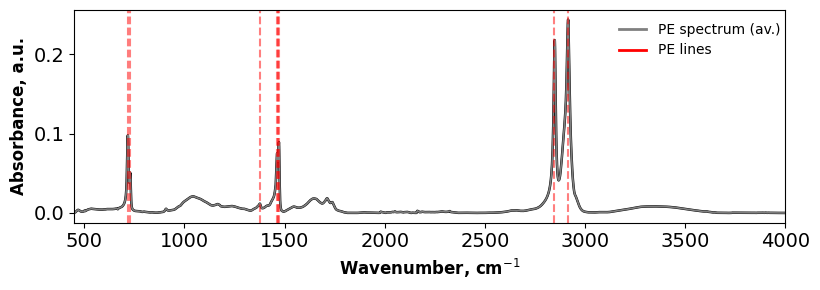

Adv1.1_5.csv [[['HDPE', 'PA'], 0.5513595]]
Adv2.2_3.csv [[['HDPE', 'PA'], 0.96720743]]
Adv_1.2_10.csv [[['HDPE', 'PA'], 0.5324406]]
Adv_1.2_12.csv [[['HDPE', 'PA'], 0.6687248]]
Adv_1.3_12.csv [[['HDPE', 'PA'], 0.97040755]]
Adv_1.3_19.csv [[['LDPE', 'PA'], 0.50440735]]
Adv_1.3_51.csv [[['HDPE', 'PA'], 0.73120564]]
AI58_14_2.csv [[['HDPE', 'PA'], 0.9982414]]
AI58_30_10.csv [[['HDPE', 'PA'], 0.70741475]]
AI58_5_41.csv [[['HDPE', 'PA'], 0.2798416]]
AI58_5_62.csv [[['HDPE', 'PA'], 0.75225353]]
AI58_5_66.csv [[['HDPE', 'PA'], 0.68672454]]
AI58_5_222.csv [[['HDPE', 'PA'], 0.5178437]]
AI58_5.1_20.csv [[['HDPE', 'PA'], 0.9715686]]
AI58_5.1_22.csv [[['HDPE', 'PA'], 0.90611976]]
AI58_5.1_27.csv [[['LDPE', 'PA'], 0.28463915]]
AI58_5.1_29.csv [[['HDPE', 'PA'], 0.9827311]]
AI58_5.1_35.csv [[['HDPE', 'PA'], 0.92042714]]
AI58_5.1_38.csv [[['HDPE', 'PA'], 0.7184357]]
AI58_5.1_48.csv [[['HDPE', 'PA'], 0.36088932]]
AI58_5.1_52.csv [[['HDPE', 'PA'], 0.61109394]]
AI58_5.1_56.csv [[['HDPE', 'PA'], 0.3784744

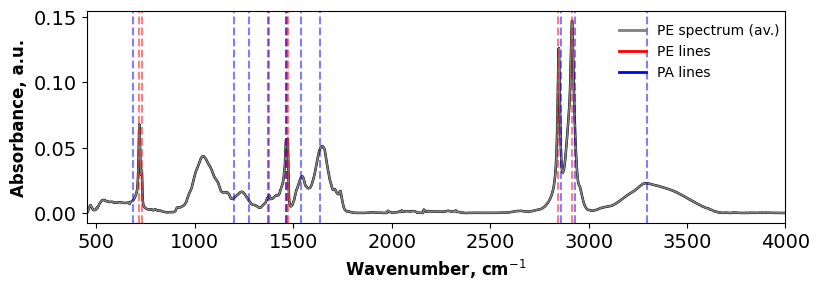

Adv_1.2_17.csv [[['HDPE', 'PVC'], 0.49875855]]
AI58_35_3.1.csv [[['HDPE', 'PVC'], 0.63348633]]
AI58_35_7.csv [[['HDPE', 'PVC'], 0.28752455]]
AI58_42_1.csv [[['HDPE', 'PVC'], 0.6132373]]
AI58_4_2.csv [[['HDPE', 'PVC'], 0.34031203]]
AI58_4_15.csv [[['HDPE', 'PVC'], 0.4456347]]
AI58_4_17.csv [[['HDPE', 'PVC'], 0.5176678]]
AI58_5_2.csv [[['HDPE', 'PVC'], 0.80936205]]
AI58_5_33.csv [[['HDPE', 'PVC'], 0.4610532]]
AI58_5_42.csv [[['HDPE', 'PVC'], 0.7975942]]
AI58_5_53.csv [[['HDPE', 'PVC'], 0.4738397]]
AI58_5_65.csv [[['HDPE', 'PVC'], 0.27392158]]
AI58_5_81.csv [[['HDPE', 'PVC'], 0.45637703]]
AI58_5_113.csv [[['HDPE', 'PVC'], 0.30709273]]
AI58_5_190.csv [[['HDPE', 'PVC'], 0.6966882]]
AI58_5_193.csv [[['HDPE', 'PVC'], 0.8439561]]
AI58_5_197.csv [[['HDPE', 'PVC'], 0.6148927]]
AI58_5_200.csv [[['HDPE', 'PVC'], 0.7370608]]
AI58_5_246.csv [[['HDPE', 'PVC'], 0.66931045]]
AI58_5.1_2.csv [[['HDPE', 'PVC'], 0.83024323]]
AI58_5.1_4.csv [[['HDPE', 'PVC'], 0.8338087]]
AI58_5.1_5.csv [[['HDPE', 'PVC'], 0.

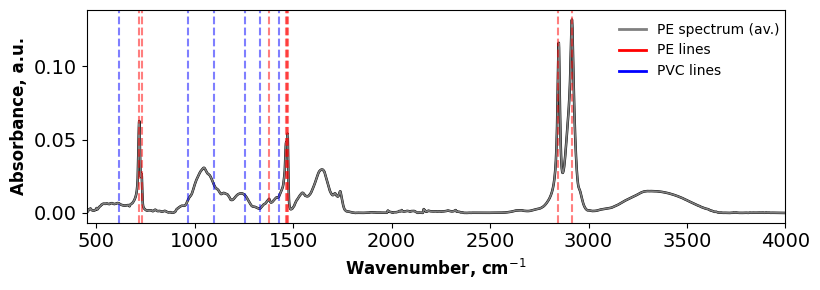

Adv_1.3_5.csv [[['HDPE', 'PET'], 0.54260695]]


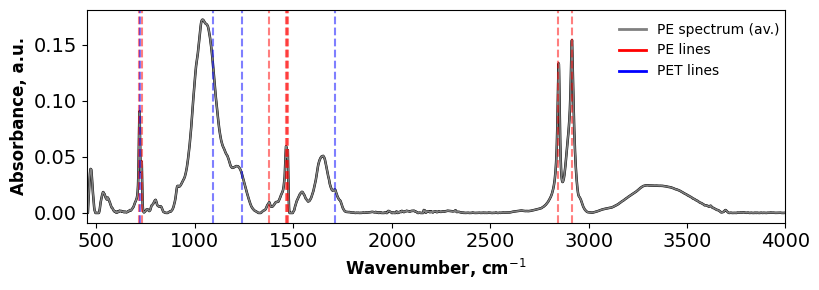

Adv_1.3_23.csv [[['HDPE', 'PU'], 0.51848954]]
AI58_5_29.csv [[['HDPE', 'PU'], 0.39614847]]
AI58_5_46.csv [[['HDPE', 'PU'], 0.33066535]]
AI58_5_48.csv [[['HDPE', 'PU'], 0.30697185]]
AI58_5_132.csv [[['HDPE', 'PU'], 0.5217722]]
AI58_5_140.csv [[['HDPE', 'PU'], 0.5340787]]
AI58_5_145.csv [[['HDPE', 'PU'], 0.53143644]]
AI58_5_214.csv [[['HDPE', 'PU'], 0.3765838]]
AI58_5.1_17.csv [[['HDPE', 'PU'], 0.6943579]]
AI58.1_186.csv [[['PU', 'LDPE'], 0.8190673]]
AI58.1_209.csv [[['PU', 'LDPE'], 0.38718057]]
AI58_5.2_28.csv [[['HDPE', 'PU'], 0.3106345]]
AI58_5.2_34.csv [[['HDPE', 'PU'], 0.43133456]]
AI58_5.2_36.csv [[['HDPE', 'PU'], 0.5372432]]
AI58_5.2_57.csv [[['HDPE', 'PU'], 0.59532934]]
AI58_5.2_84.csv [[['HDPE', 'PU'], 0.33830124]]
AI58_5.2_88.csv [[['HDPE', 'PU'], 0.42678425]]
AI58_5.2_127.csv [[['PU', 'LDPE'], 0.3206838]]
AI58_5.2_140.csv [[['HDPE', 'PU'], 0.5246395]]
AI58_5.2_163.csv [[['PU', 'LDPE'], 0.23478505]]
AI58_5.2_228.csv [[['PU', 'LDPE'], 0.37580425]]
AI58_5.2_232.csv [[['HDPE', 'PU

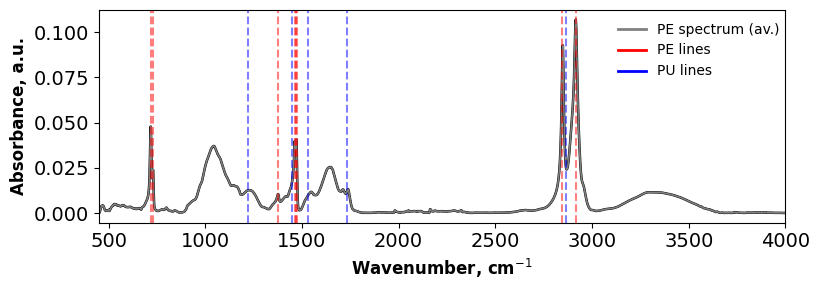

Adv_1.3_36.csv [[['HDPE', 'PP'], 0.9920008]]
AI58_5_206.csv [[['HDPE', 'PP'], 0.8539511]]
AI58_5.1_240.csv [[['LDPE', 'PP'], 0.45817938]]


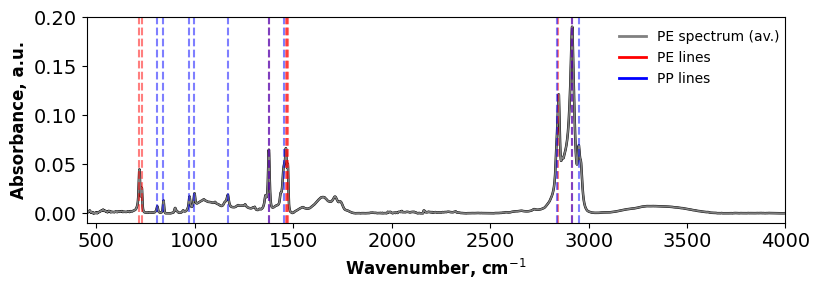

AI58_10_3.csv [[['HDPE', 'CPE'], 0.74861854]]
AI58_27_19.csv [[['HDPE', 'CPE'], 0.4889661]]
AI58_3_1.csv [[['HDPE', 'CPE'], 0.6616812]]
AI58_42_7.1.csv [[['LDPE', 'CPE'], 0.71605694]]
AI58_44_1.1.csv [[['HDPE', 'CPE'], 0.75918883]]
AI58_5_5.csv [[['LDPE', 'CPE'], 0.9777928]]
AI58_5_43.csv [[['HDPE', 'CPE'], 0.9792118]]
AI58_5_97.csv [[['HDPE', 'CPE'], 0.2617189]]
AI58_5_117.csv [[['HDPE', 'CPE'], 0.29298344]]
AI58_5_253.csv [[['HDPE', 'CPE'], 0.48423198]]
AI58_5_270.csv [[['LDPE', 'CPE'], 0.99785304]]
AI58_5.1_79.csv [[['LDPE', 'CPE'], 0.40092582]]
AI58.1_152.csv [[['HDPE', 'CPE'], 0.61433035]]
AI58_5.2_4.csv [[['HDPE', 'CPE'], 0.968764]]
AI58_5.2_14.csv [[['HDPE', 'CPE'], 0.3563844]]
AI58_5.2_17.csv [[['HDPE', 'CPE'], 0.2886196]]
AI58_5.2_20.csv [[['HDPE', 'CPE'], 0.45124882]]
AI58_5.2_71.csv [[['HDPE', 'CPE'], 0.46825802]]
AI58_5.2_78.csv [[['HDPE', 'CPE'], 0.54453564]]
AI58_5.2_289.csv [[['HDPE', 'CPE'], 0.24944136]]
AI58_6_44.csv [[['HDPE', 'CPE'], 0.28681225]]
AI58_6_201.csv [[['L

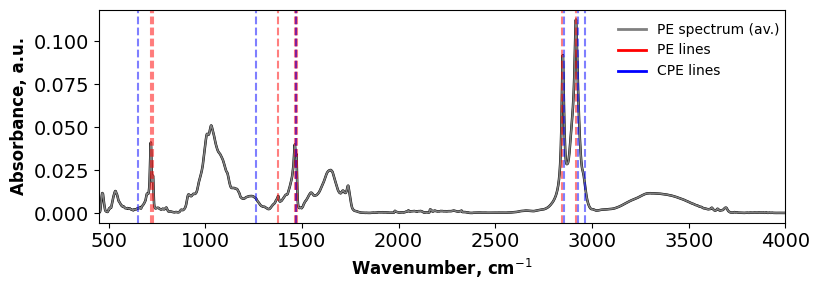

AI58_10_6.csv [[['CA', 'LDPE'], 0.32544455]]


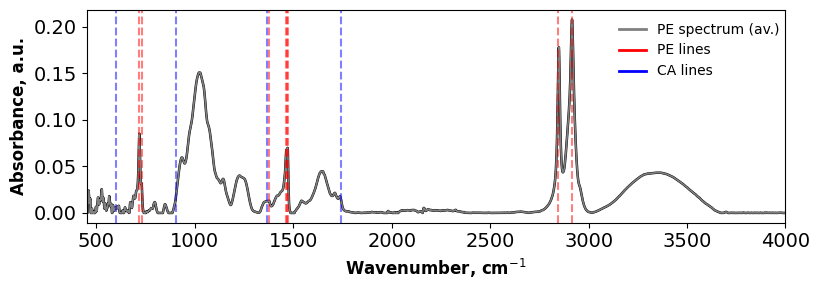

AI58_17_1.csv [[['HDPE', 'PC'], 0.28502327]]
AI58_5_180.csv [[['HDPE', 'PC'], 0.3433309]]
AI58.1_118.csv [[['HDPE', 'PC'], 0.28814012]]
AI58_5.2_209.csv [[['HDPE', 'PC'], 0.47370365]]


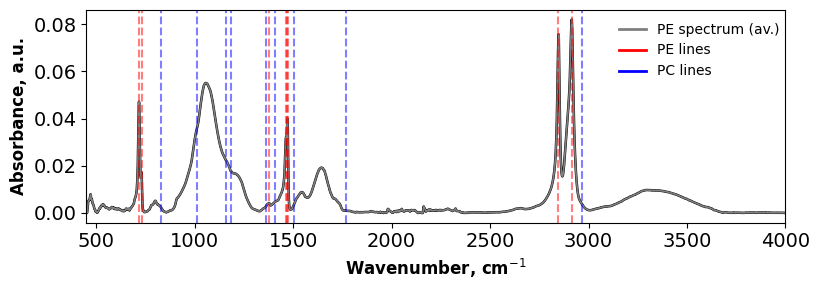

AI58_5_57.csv [[['LDPE', 'EVA'], 0.88828456]]
AI58_5_78.csv [[['LDPE', 'EVA'], 0.38714647]]
AI58_5_227.csv [[['LDPE', 'EVA'], 0.8874809]]
AI58_5_314.csv [[['LDPE', 'EVA'], 0.9987893]]
AI58.1_119.csv [[['LDPE', 'EVA'], 0.7233284]]
AI58.1_214.csv [[['LDPE', 'EVA'], 0.9731259]]
AI58_5.2_224.1.csv [[['LDPE', 'EVA'], 0.87160504]]
AI58_5.2_294.csv [[['LDPE', 'EVA'], 0.9263314]]
AI58_5.2_297.csv [[['LDPE', 'EVA'], 0.55914176]]
AI58_5.2_363.csv [[['LDPE', 'EVA'], 0.98059875]]
AI58_5.2_405.csv [[['LDPE', 'EVA'], 0.998719]]
AI58_5.2_406.csv [[['LDPE', 'EVA'], 0.9131976]]
AI58_6_69.csv [[['HDPE', 'EVA'], 0.4020087]]
AI58_6_246.csv [[['LDPE', 'EVA'], 0.31767085]]


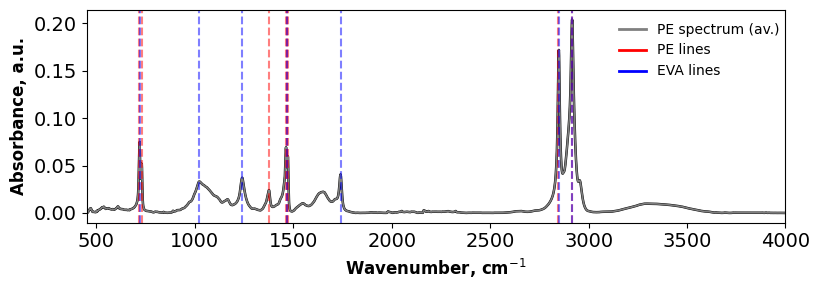

AI58_5.1_15.csv [[['PA', 'PP'], 0.72690177]]
AI58_5.1_28.csv [[['PA', 'PP'], 0.78572214]]


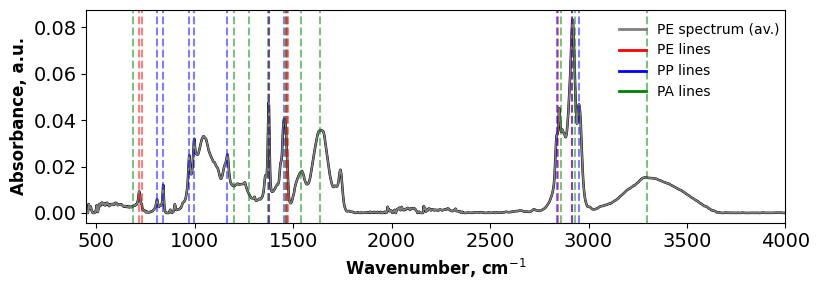

AI58_5.1_23.csv [[['PA', 'CPE'], 0.41087434]]
AI58_5.2_66.csv [[['PA', 'CPE'], 0.5360995]]
AI58_6_45.csv [[['PA', 'CPE'], 0.48476326]]
AI58_6_183.csv [[['PA', 'CPE'], 0.95646685]]
AI58_6_189.csv [[['PA', 'CPE'], 0.6813707]]
AI58_6_203.csv [[['PA', 'CPE'], 0.68356246]]
AI58_7_6.csv [[['PA', 'CPE'], 0.7849384]]
AMK82_35_38.1.csv [[['PA', 'CPE'], 0.69705147]]
AMK82_36_37.csv [[['PA', 'CPE'], 0.53055936]]


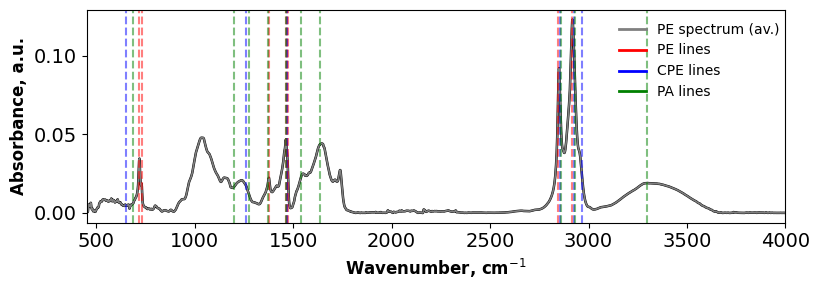

AI58_5.1_26.csv [[['PU', 'PA'], 0.56410205]]
AI58_6_17.csv [[['PU', 'PA'], 0.42094997]]


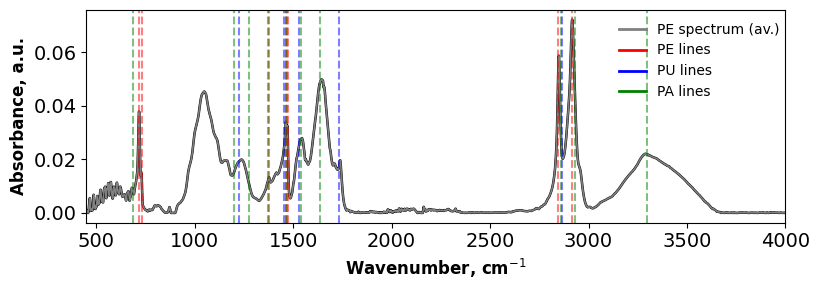

AI58_5.1_36.csv [[['PA', 'PVC'], 0.29444304]]
AI58_5.2_6.csv [[['PA', 'PVC'], 0.49202374]]
AI58_6_216.csv [[['PA', 'PVC'], 0.6139199]]


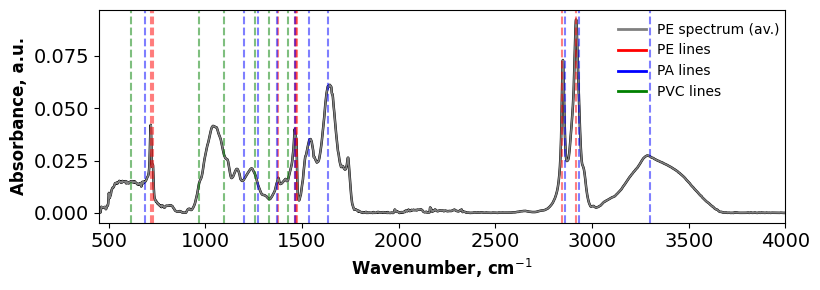

AI58.1_202.csv [[['CPE', 'EVA'], 0.44408056]]
AI58_6_295.csv [[['CPE', 'EVA'], 0.42630765]]


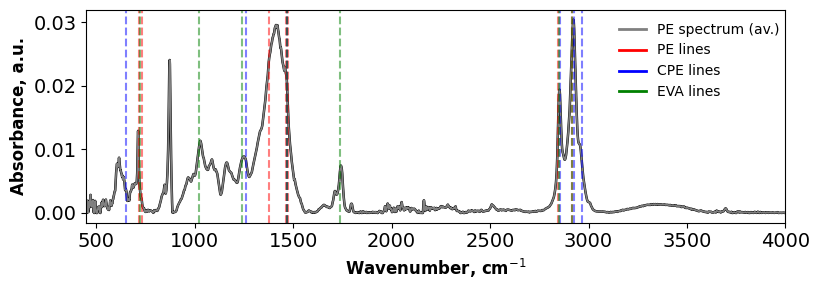

AI58_5.2_102.csv [[['PA', 'EVA'], 0.5884261]]


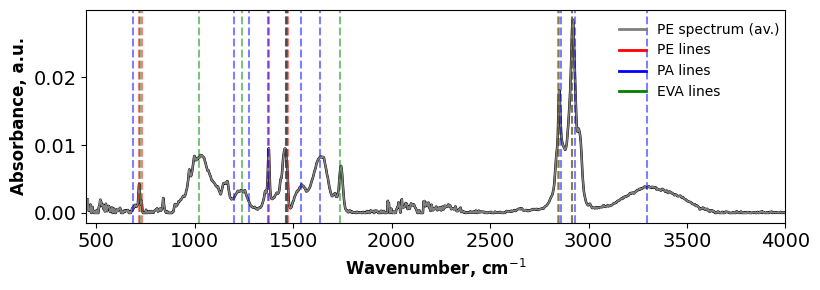

AI58_6_118.csv [[['PP', 'CPE'], 0.3875821]]


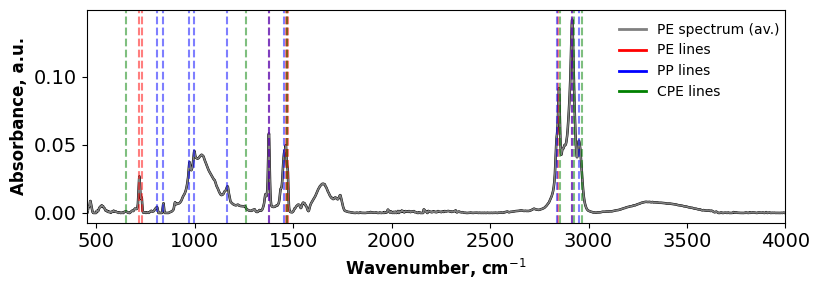

AMK82_34_7.csv [[['PU', 'CPE'], 0.52389836]]


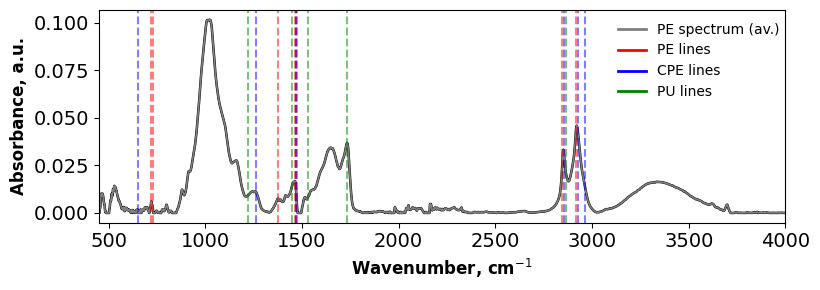

Adv1.1_6.csv [[['PP'], 0.4688219]]
Adv1.1_14.csv [[['PP'], 0.2781987]]
Adv_1.2_16.csv [[['PP'], 0.8051421]]
Adv_1.3_9.csv [[['PP'], 0.50476015]]
Adv_1.3_39.csv [[['PP'], 0.81586957]]
Adv_1.3_47.csv [[['PP'], 0.46672818]]
Adv_1.3_53.csv [[['PP'], 0.80107635]]
Adv_1.3_68.csv [[['PP'], 0.7307248]]
AI58_12_4.csv [[['PP'], 0.83863837]]
AI58_12_7.csv [[['PP'], 0.56009924]]
AI58_23_5.csv [[['PP'], 0.8732099]]
AI58_27_5.csv [[['PP'], 0.39022017]]
AI58_35_1.csv [[['PP'], 0.6098578]]
AI58_35_5.csv [[['PP'], 0.9278264]]
AI58_35_28.csv [[['PP'], 0.37155804]]
AI58_35_36.csv [[['PP'], 0.5086743]]
AI58_35_43.csv [[['PP'], 0.6928855]]
AI58_36_7.csv [[['PP'], 0.37153056]]
AI58_40_2.csv [[['PP'], 0.6628523]]
AI58_4_31.csv [[['PP'], 0.666468]]
AI58_4_34.csv [[['PP'], 0.74395746]]
AI58_4_36.csv [[['PP'], 0.9610344]]
AI58_4_42.csv [[['PP'], 0.8828035]]
AI58_5_14.csv [[['PP'], 0.55735517]]
AI58_5_21.csv [[['PP'], 0.54058814]]
AI58_5_67.csv [[['PP'], 0.9269975]]
AI58_5_120.csv [[['PP'], 0.85481495]]
AI58_5_1

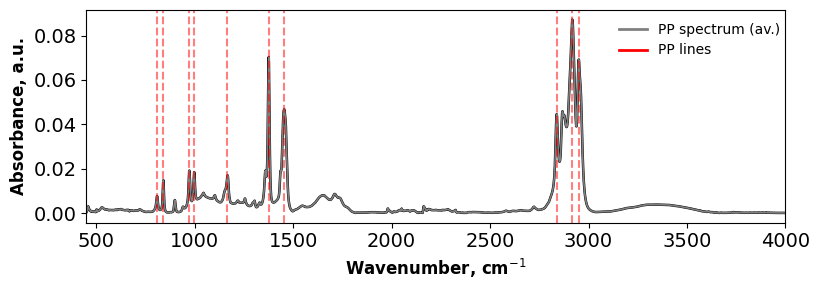

Adv_1.3_1.csv [[['PU', 'PP'], 0.31193745]]
AI58_35_6.csv [[['PU', 'PP'], 0.3258263]]
Templfj_1_1.csv [[['PU', 'PP'], 0.32754079]]


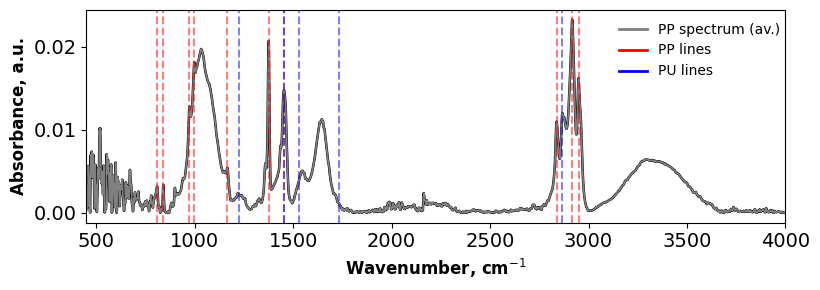

Adv_1.3_6.csv [[['PA', 'PP'], 0.6950774]]
Adv_1.3_8.csv [[['PA', 'PP'], 0.5214153]]
Adv_1.3_26.csv [[['PA', 'PP'], 0.97019243]]
Adv_1.3_28.csv [[['PA', 'PP'], 0.5961881]]
Adv_1.3_31.csv [[['PA', 'PP'], 0.35097292]]
Adv_1.3_38.csv [[['PA', 'PP'], 0.97535765]]
Adv_1.3_41.csv [[['PA', 'PP'], 0.70666635]]
Adv_1.3_44.csv [[['PA', 'PP'], 0.7419684]]
AI58_12_8.csv [[['PA', 'PP'], 0.86517674]]
AI58_13_4.csv [[['PA', 'PP'], 0.904325]]
AI58_27_11.csv [[['PA', 'PP'], 0.42319423]]
AI58_33_2.csv [[['PA', 'PP'], 0.8349627]]
AI58_35_23.csv [[['PA', 'PP'], 0.5751331]]
AI58_35_38.csv [[['PA', 'PP'], 0.75662476]]
AI58_37_7.csv [[['PA', 'PP'], 0.78115803]]
AI58_3_6.csv [[['PA', 'PP'], 0.90481967]]
AI58_5_54.csv [[['PA', 'PP'], 0.29593906]]
AI58_5_60.csv [[['PA', 'PP'], 0.8185701]]
AI58_5_147.csv [[['PA', 'PP'], 0.86837345]]
AI58_5_157.csv [[['PA', 'PP'], 0.47050726]]
AI58_5_160.csv [[['PA', 'PP'], 0.79735494]]
AI58_5_163.csv [[['PA', 'PP'], 0.42959088]]
AI58_5_168.csv [[['PA', 'PP'], 0.6116972]]
AI58_5_1

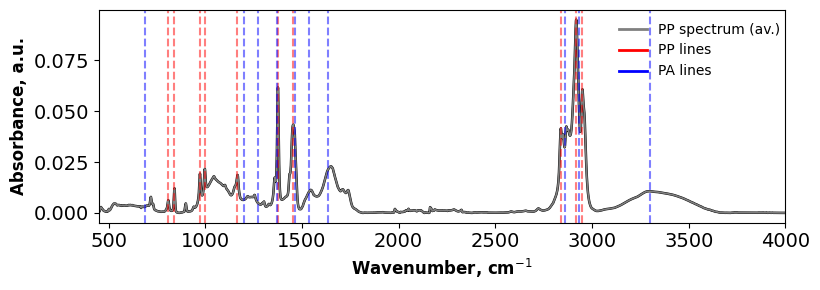

Adv_1.3_32_001.csv [[['PP', 'PVC'], 0.3642822]]
Adv_1.3_34.csv [[['PP', 'PVC'], 0.2628975]]
AI58_27_9.csv [[['PP', 'PVC'], 0.25379127]]
AI58_27_12.csv [[['PP', 'PVC'], 0.74977887]]
AI58_27_14.csv [[['PP', 'PVC'], 0.5907572]]
AI58_32_2.csv [[['PP', 'PVC'], 0.34823108]]
AI58_33_1.csv [[['PP', 'PVC'], 0.6646822]]
AI58_35_24.csv [[['PP', 'PVC'], 0.9290742]]
AI58_35_32.csv [[['PP', 'PVC'], 0.37406373]]
AI58_3_5_001.csv [[['PP', 'PVC'], 0.88421553]]
AI58_42_2.csv [[['PP', 'PVC'], 0.70024496]]
AI58_5_31.csv [[['PP', 'PVC'], 0.59220386]]
AI58_5_103.csv [[['PP', 'PVC'], 0.35169798]]
AI58_5_154.csv [[['PP', 'PVC'], 0.4325287]]
AI58_5_158.1.csv [[['PP', 'PVC'], 0.4982312]]
AI58_5_170.csv [[['PP', 'PVC'], 0.34711912]]
AI58_5_171.csv [[['PP', 'PVC'], 0.43030515]]
AI58_5_188.1.csv [[['PP', 'PVC'], 0.52761734]]
AI58_5_196.csv [[['PP', 'PVC'], 0.604733]]
AI58_5_205.csv [[['PP', 'PVC'], 0.43978435]]
AI58_5_217.csv [[['PP', 'PVC'], 0.6396477]]
AI58_5_231.csv [[['PP', 'PVC'], 0.2728145]]
AI58_5_267.csv [

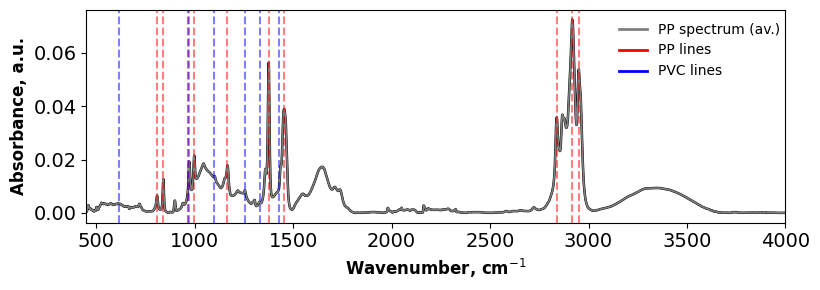

Adv_1.3_40.csv [[['PP', 'CPE'], 0.5704543]]
Adv_1.3_60.csv [[['PP', 'CPE'], 0.7051084]]
AI58_4_4.csv [[['PP', 'CPE'], 0.52398425]]
AI58_5_3.csv [[['PP', 'CPE'], 0.7099985]]
AI58_5_92.csv [[['PP', 'CPE'], 0.19645697]]
AI58_5_240.csv [[['PP', 'CPE'], 0.8587723]]
AI58_5_271.csv [[['PP', 'CPE'], 0.52088916]]
AI58_5_278.csv [[['PP', 'CPE'], 0.86900985]]
AI58_5_280.csv [[['PP', 'CPE'], 0.4739545]]
AI58_5_309.csv [[['PP', 'CPE'], 0.81075555]]
AI58_5.1_88.csv [[['PP', 'CPE'], 0.88881725]]
AI58_5.1_99.csv [[['PP', 'CPE'], 0.62296593]]
AI58.1_127.csv [[['PP', 'CPE'], 0.98090696]]
AI58.1_128.csv [[['PP', 'CPE'], 0.76260006]]
AI58.1_131.csv [[['PP', 'CPE'], 0.6202493]]
AI58.1_132.csv [[['PP', 'CPE'], 0.84952587]]
AI58.1_133.csv [[['PP', 'CPE'], 0.6641682]]
AI58.1_134.csv [[['PP', 'CPE'], 0.96058834]]
AI58.1_136.csv [[['PP', 'CPE'], 0.88652784]]
AI58.1_139.csv [[['PP', 'CPE'], 0.3906633]]
AI58.1_140.csv [[['PP', 'CPE'], 0.63234943]]
AI58.1_158.csv [[['PP', 'CPE'], 0.72025955]]
AI58.1_163.csv [[['PP

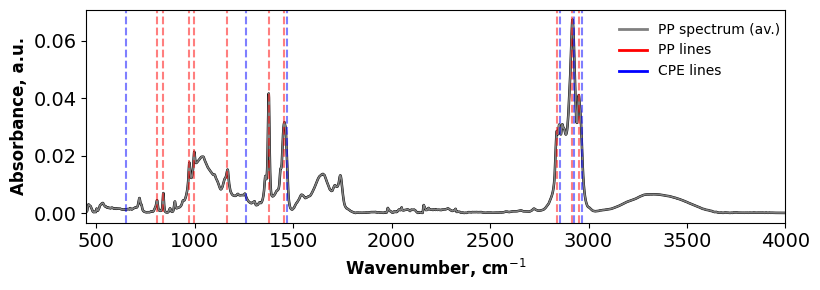

AI58_12_9.csv [[['PC', 'PP'], 0.27583465]]
AI58_35_10.csv [[['PC', 'PP'], 0.37296644]]
AI58_5_156.csv [[['PC', 'PP'], 0.38780698]]
AI58_6_58.csv [[['PC', 'PP'], 0.28965497]]
AI58_6_290.csv [[['PC', 'PP'], 0.30890587]]
AI58_7_119.csv [[['PC', 'PP'], 0.2708035]]


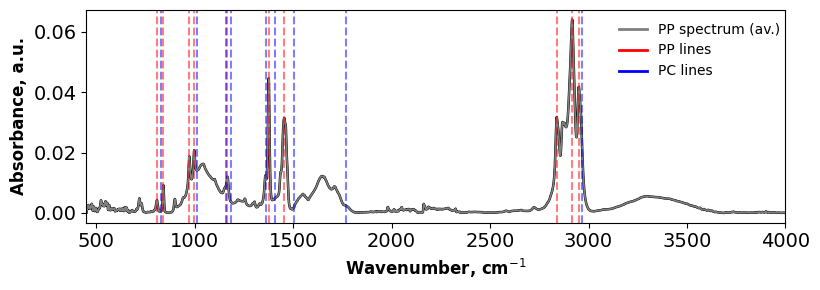

AI58_4_13.csv [[['CA', 'PP'], 0.55648935]]


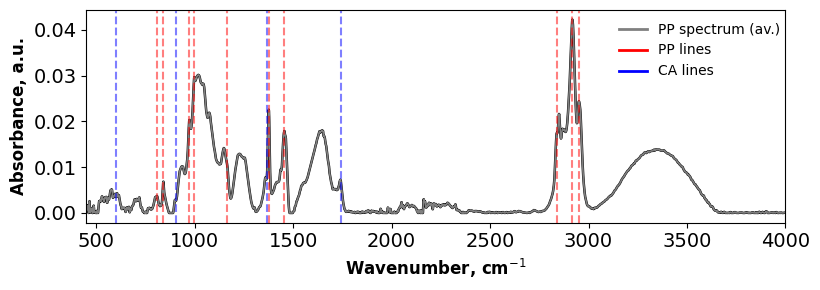

AI58_5_63.csv [[['HDPE', 'PP'], 0.61864865]]
AI58_7_109.csv [[['LDPE', 'PP'], 0.9814266]]
AMK86_7203_2.csv [[['HDPE', 'PP'], 0.6323768]]


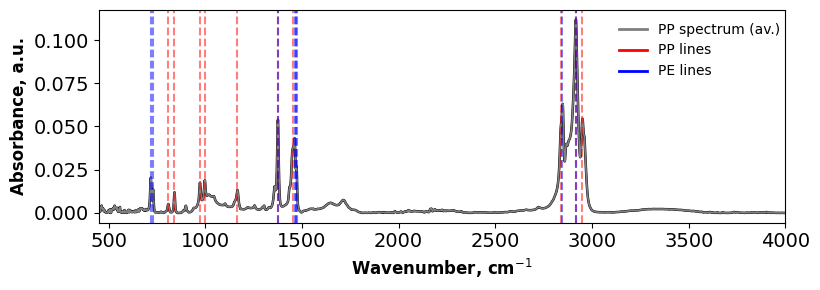

AI58_5.2_3.csv [[['CPE', 'EVA'], 0.5321349]]


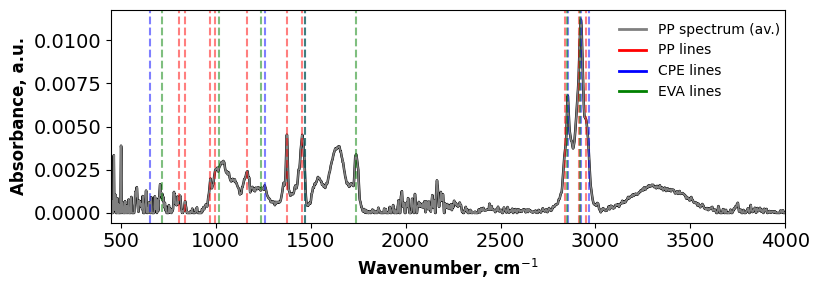

AI58_5.2_145.csv [[['PP', 'PS'], 0.82744366]]
AI58_5.2_384.csv [[['PP', 'PS'], 0.24830134]]


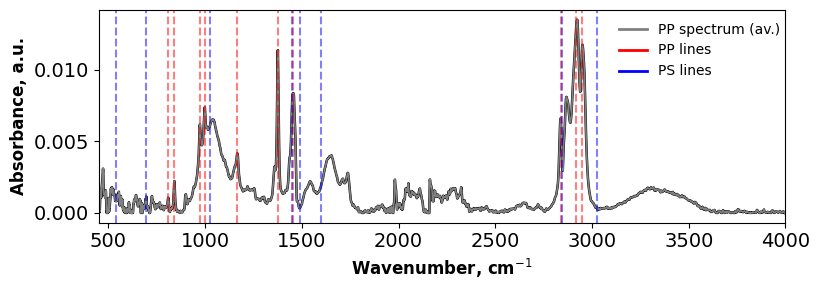

AI58_6_271.csv [[['PP', 'EVA'], 0.45493388]]


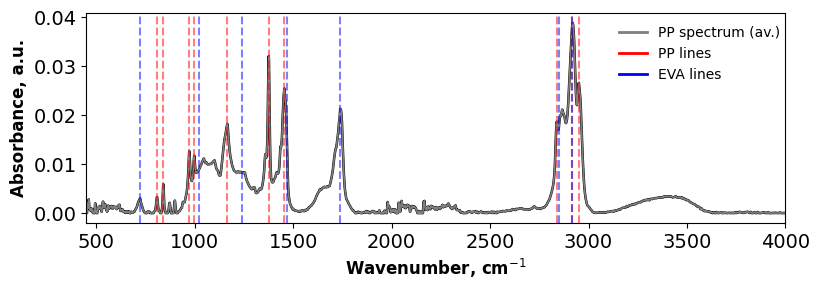

Templfj_3_2.csv [[['LDPE'], 0.48007265]]


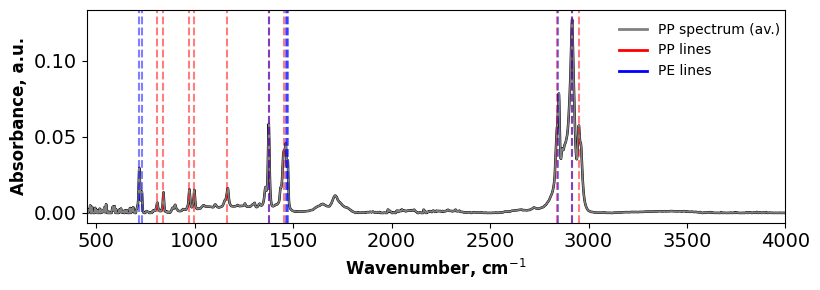

Adv_1.3_61.csv [[['PS'], 0.99931616]]
AI58_13_8.csv [[['PS'], 0.9929394]]
AI58_16_1.csv [[['PS'], 0.9926458]]
AI58_18_1.1.csv [[['PS'], 0.9320022]]
AI58_18_2.csv [[['PS'], 0.9953554]]
AI58_19_1.csv [[['PS'], 0.9987512]]
AI58_1_17.csv [[['PS'], 0.914091]]
AI58_22_1.csv [[['PS'], 0.9993537]]
AI58_23_1.csv [[['PS'], 0.9256999]]
AI58_23_2.csv [[['PS'], 0.44092497]]
AI58_25_1.csv [[['PS'], 0.9942356]]
AI58_25_2.csv [[['PS'], 0.99988216]]
AI58_25_3.csv [[['PS'], 0.9997587]]
AI58_25_4.csv [[['PS'], 0.99932075]]
AI58_27_1.csv [[['PS'], 0.99278396]]
AI58_27_2.csv [[['PS'], 0.999155]]
AI58_27_4.csv [[['PS'], 0.99919236]]
AI58_27_6.csv [[['PS'], 0.9989808]]
AI58_28_1.csv [[['PS'], 0.9997005]]
AI58_29_1.csv [[['PS'], 0.9994679]]
AI58_2_7.csv [[['PS'], 0.8126655]]
AI58_30_1.csv [[['PS'], 0.9970293]]
AI58_35_12.csv [[['PS'], 0.99955606]]
AI58_36_2.csv [[['PS'], 0.99984276]]
AI58_37_1.csv [[['PS'], 0.9996189]]
AI58_3_7.csv [[['PS'], 0.99478364]]
AI58_4_1.csv [[['PS'], 0.99848735]]
AI58_4_7.csv [[['PS

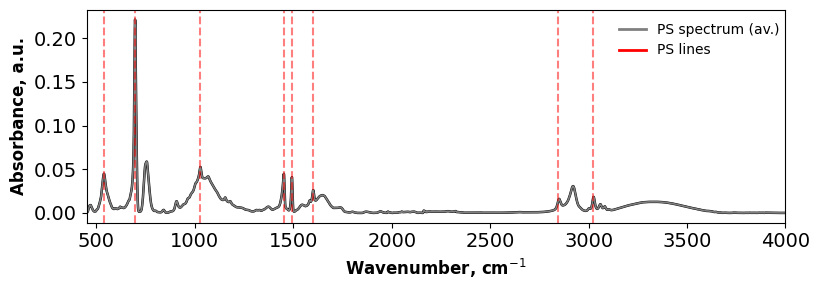

AI58_3_2.csv [[['PS', 'PVC'], 0.90982604]]
AI58_3_3.csv [[['PS', 'PVC'], 0.80751854]]
AI58_4_10.csv [[['PS', 'PVC'], 0.55590737]]
AMK82_10_1.csv [[['PS', 'PVC'], 0.8188663]]
AMK82_23_2.csv [[['PS', 'PVC'], 0.8475221]]
AMK86_7274_4.csv [[['PS', 'PVC'], 0.76948]]
Templfj_1_10.csv [[['PS', 'PVC'], 0.6390814]]


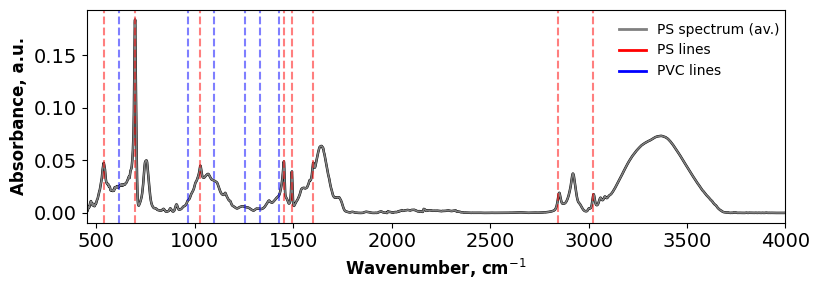

AI58_6_187.csv [[['PS', 'CPE'], 0.529723]]


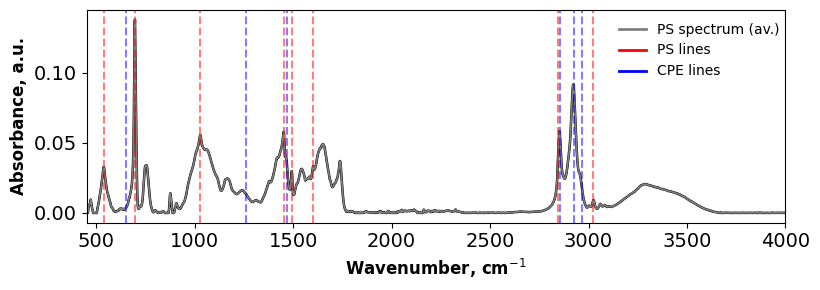

AMK82_35_24.csv [[['PA', 'PS'], 0.43058455]]
AMK82_39_12.csv [[['PA', 'PS'], 0.73189306]]
AMK86_7273_1.1.csv [[['PA', 'PS'], 0.8476801]]


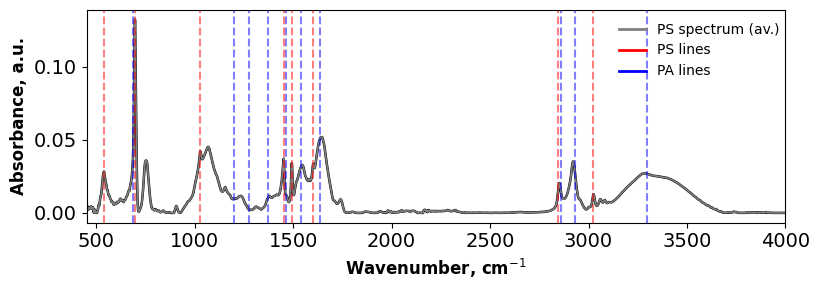

In [36]:
for true_class in ['PE', 'PP', 'PS']:
    unique_predicted_values = df.loc[df["true"] == true_class, "predicted"].unique()
    for pred_class in unique_predicted_values:
        evaluate(true_=true_class, predicted_=pred_class, panel_label_symbol_='')